# Mohr's Circle

**Companion notebook to Chapter 17 — Mohr's Circle.**

A strain gage measures strain in exactly one direction — the direction of its sensing grid. Yet inside a loaded structure, strain exists in every direction at once, and the reading from any single gage depends entirely on how that gage happens to be oriented relative to the principal directions. *Mohr's circle* is the graphical construction that makes this orientation-dependence visible: it maps every possible rotation of a two-dimensional stress element onto a single circle, where the horizontal coordinate is normal stress $\sigma$ and the vertical coordinate is shear stress $\tau$.

For the strain measurement engineer, the payoff is *rosette analysis*. Given readings from three gages in known orientations, we need to recover the complete plane-stress state — three independent quantities ($\sigma_x$, $\sigma_y$, $\tau_{xy}$), or equivalently the principal stresses and their angle ($\sigma_1$, $\sigma_2$, $\theta_p$). Mohr's circle is the geometry behind that transformation, and constructing it is still the clearest way to understand where the rosette equations come from and what the principal quantities physically mean.

**This notebook** reproduces the worked example of Chapter 17 and lets you explore your own stress states. It:
1. builds Mohr's circle and computes the principal stresses, maximum in-plane shear, and principal angle for any 2D stress state you define, and
2. sweeps the element through a full 0°–90° rotation to show how $\sigma_{x'}$, $\sigma_{y'}$, and $\tau_{x'y'}$ evolve — the same information the circle encodes, plotted as curves.

---

## Background: the circle in stress space

Mohr's circle turns the plane-stress transformation into geometry. A stress state is fixed by three numbers — the normal stresses $\sigma_x$ and $\sigma_y$ and the shear stress $\tau_{xy}$ — and from them the circle is completely determined by a center and a radius.

The center sits on the normal-stress axis, at the *average* normal stress:

$$\sigma_{avg} = \frac{\sigma_x + \sigma_y}{2} \qquad (17.1)$$

In words: the circle is centered at the mean of the two face normal stresses; shear moves the plotted points off the axis but never shifts the center.

The radius measures how far the state sits from that average — it combines the normal-stress difference and the shear:

$$R = \sqrt{\left(\frac{\sigma_x - \sigma_y}{2}\right)^2 + \tau_{xy}^2} \qquad (17.2)$$

In words: $R$ is the hypotenuse of a right triangle whose legs are the half-difference of the normal stresses and the shear stress.

The **principal stresses** are simply the two points where the circle crosses the horizontal axis — the largest and smallest normal stresses available at that point, where the shear vanishes:

$$\sigma_1 = \sigma_{avg} + R, \qquad \sigma_2 = \sigma_{avg} - R \qquad (17.3)$$

The **maximum in-plane shear stress** is the top (and bottom) of the circle, so it equals the radius:

$$\tau_{max} = R \qquad (17.4)$$

Finally, the **principal angle** $\theta_p$ — the physical rotation from the $x$-face to the $\sigma_1$ direction — is read from the circle, remembering that angles *on the circle* are twice the physical angle:

$$2\theta_p = \operatorname{atan2}\!\left(2\tau_{xy},\; \sigma_x - \sigma_y\right) \qquad (17.5)$$

In words: a plane rotated by $\theta_p$ in the real element corresponds to a point rotated by $2\theta_p$ around the circle. Using the two-argument arctangent keeps $\theta_p$ in the correct quadrant, even for pure shear ($\sigma_x = \sigma_y$).

In [1]:
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
})

# Figures generated here are the ones that appear in the book. The path is
# relative to the notebooks/ directory; on Colab it simply writes to a scratch
# folder. Do not change these filenames — the chapter includes them by name.
OUT_DIR = Path("../src/media/ch17")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DPI = 150  # resolution of the saved book figures

## Input: define the stress state

Everything downstream flows from three numbers. Edit them below and re-run the notebook to analyze any plane-stress state. The defaults are the worked example from Chapter 17. Units are arbitrary (MPa, ksi, psi) — just be consistent, since Mohr's circle is purely geometric and carries no material properties of its own.

In [2]:
# --- USER INPUT (defaults reproduce the Chapter 17 worked example) ---
sigma_x = 80.0    # Normal stress on x-face
sigma_y = 20.0    # Normal stress on y-face
tau_xy  = 40.0    # Shear stress on x-face (positive = counterclockwise, tensor convention)
units   = 'MPa'   # Label only — does not affect the calculations

## Calculations

The function below applies Eqs. (17.1)–(17.5) directly: center, radius, the two principal stresses, the maximum in-plane shear, and the principal angle. Wrapping the arithmetic in a single function keeps it reusable — you can call it on measured data later — and makes each output traceable to its equation.

In [3]:
def mohr_circle_stress(sigma_x, sigma_y, tau_xy):
    """Compute Mohr's-circle quantities for a 2D (plane) stress state.

    Parameters
    ----------
    sigma_x, sigma_y : float
        Normal stresses on the x- and y-faces, in any consistent stress unit.
    tau_xy : float
        Shear stress on the x-face (tensor convention: positive acts on the
        +x face in the +y direction, i.e. counterclockwise).

    Returns
    -------
    dict
        ``sigma_avg`` (center), ``R`` (radius), principal stresses ``sigma_1``
        and ``sigma_2``, maximum in-plane shear ``tau_max``, and the principal
        angle ``theta_p`` in degrees (rotation from the x-axis to sigma_1).
    """
    sigma_avg = (sigma_x + sigma_y) / 2.0                 # Eq. (17.1)
    R = np.hypot((sigma_x - sigma_y) / 2.0, tau_xy)       # Eq. (17.2)

    # Eq. (17.5). atan2 keeps the angle in the correct quadrant and returns
    # +/-90 deg for pure shear (sigma_x == sigma_y), so no special case needed.
    two_theta_p = np.arctan2(2.0 * tau_xy, sigma_x - sigma_y)
    theta_p = np.degrees(two_theta_p) / 2.0

    return {
        "sigma_avg": sigma_avg,
        "R": R,
        "sigma_1": sigma_avg + R,   # Eq. (17.3)
        "sigma_2": sigma_avg - R,   # Eq. (17.3)
        "tau_max": R,               # Eq. (17.4)
        "theta_p": theta_p,
    }


state = mohr_circle_stress(sigma_x, sigma_y, tau_xy)
sigma_avg = state["sigma_avg"]
R         = state["R"]
sigma_1   = state["sigma_1"]
sigma_2   = state["sigma_2"]
tau_max   = state["tau_max"]
theta_p   = state["theta_p"]

print("Input stress state")
print(f"  σx  = {sigma_x:>10.3f} {units}")
print(f"  σy  = {sigma_y:>10.3f} {units}")
print(f"  τxy = {tau_xy:>10.3f} {units}")
print()
print("Mohr's Circle")
print(f"  Center  σ_avg = {sigma_avg:>10.3f} {units}")
print(f"  Radius  R     = {R:>10.3f} {units}")
print()
print("Principal stresses")
print(f"  σ₁ = {sigma_1:>10.3f} {units}  (maximum normal stress)")
print(f"  σ₂ = {sigma_2:>10.3f} {units}  (minimum normal stress)")
print(f"  τ_max = {tau_max:>8.3f} {units}  (maximum in-plane shear)")
print()
print("Principal angle")
print(f"  θp = {theta_p:>8.3f}°  (rotation from x-axis to σ₁ direction)")

Input stress state
  σx  =     80.000 MPa
  σy  =     20.000 MPa
  τxy =     40.000 MPa

Mohr's Circle
  Center  σ_avg =     50.000 MPa
  Radius  R     =     50.000 MPa

Principal stresses
  σ₁ =    100.000 MPa  (maximum normal stress)
  σ₂ =      0.000 MPa  (minimum normal stress)
  τ_max =   50.000 MPa  (maximum in-plane shear)

Principal angle
  θp =   26.565°  (rotation from x-axis to σ₁ direction)


## Plot: Mohr's circle

Now we draw the circle itself. Point **A** marks the $x$-face at $(\sigma_x, \tau_{xy})$ and point **B** marks the $y$-face at $(\sigma_y, -\tau_{xy})$; the dashed line joining them is a diameter through the center. The circle's crossings of the horizontal axis are the principal stresses, and its highest point is the maximum in-plane shear. Following Chapter 17, **positive shear is plotted upward** — so point A, with $\tau_{xy} > 0$, sits above the axis. This is the plot saved as Figure 17.3 in the book.

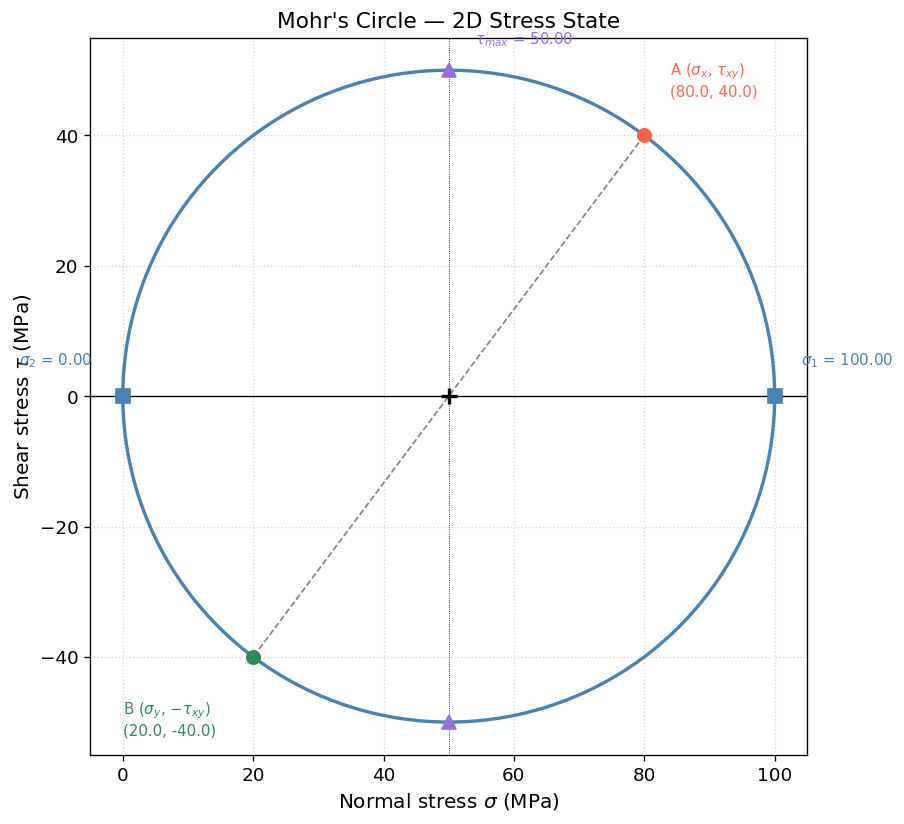

In [4]:
N_CIRCLE_POINTS = 360   # samples used to draw the circle outline

fig, ax = plt.subplots(figsize=(8, 7))

# --- Draw the circle ---
phi = np.linspace(0, 2 * np.pi, N_CIRCLE_POINTS)
circle_x = sigma_avg + R * np.cos(phi)
circle_y = R * np.sin(phi)
ax.plot(circle_x, circle_y, 'steelblue', linewidth=2)

# --- Key points ---
# Point A: x-face  (σx,  τxy)   Point B: y-face  (σy, -τxy)
ax.plot(sigma_x,   tau_xy,  'o', color='tomato',       markersize=8, zorder=5)
ax.plot(sigma_y,  -tau_xy,  'o', color='seagreen',     markersize=8, zorder=5)
ax.plot(sigma_1,   0,       's', color='steelblue',    markersize=8, zorder=5)
ax.plot(sigma_2,   0,       's', color='steelblue',    markersize=8, zorder=5)
ax.plot(sigma_avg, R,       '^', color='mediumpurple', markersize=8, zorder=5)
ax.plot(sigma_avg, -R,      '^', color='mediumpurple', markersize=8, zorder=5)

# Diameter line connecting A and B, and the center marker
ax.plot([sigma_x, sigma_y], [tau_xy, -tau_xy], '--', color='gray', linewidth=1)
ax.plot(sigma_avg, 0, '+', color='black', markersize=10, markeredgewidth=2, zorder=6)

# --- Annotations ---
offset = R * 0.08
ax.annotate(f'A ($\\sigma_x$, $\\tau_{{xy}}$)\n({sigma_x:.1f}, {tau_xy:.1f})',
            xy=(sigma_x, tau_xy), xytext=(sigma_x + offset, tau_xy + offset * 1.5),
            fontsize=9, color='tomato')
ax.annotate(f'B ($\\sigma_y$, $-\\tau_{{xy}}$)\n({sigma_y:.1f}, {-tau_xy:.1f})',
            xy=(sigma_y, -tau_xy), xytext=(sigma_y - offset * 5, -tau_xy - offset * 3),
            fontsize=9, color='seagreen')
ax.annotate(f'$\\sigma_1$ = {sigma_1:.2f}', xy=(sigma_1, 0),
            xytext=(sigma_1 + offset, offset * 1.2), fontsize=9, color='steelblue')
ax.annotate(f'$\\sigma_2$ = {sigma_2:.2f}', xy=(sigma_2, 0),
            xytext=(sigma_2 - offset * 4, offset * 1.2), fontsize=9, color='steelblue')
ax.annotate(f'$\\tau_{{max}}$ = {tau_max:.2f}', xy=(sigma_avg, R),
            xytext=(sigma_avg + offset, R + offset), fontsize=9, color='mediumpurple')

# --- Axes and grid ---
# Positive shear is plotted UPWARD, matching Chapter 17 (no y-axis inversion).
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(sigma_avg, color='black', linewidth=0.5, linestyle=':')
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel(f'Normal stress $\\sigma$ ({units})', fontsize=12)
ax.set_ylabel(f'Shear stress $\\tau$ ({units})', fontsize=12)
ax.set_title("Mohr's Circle — 2D Stress State", fontsize=13)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig17_nb1_mohrs_circle_stress.png', bbox_inches='tight', dpi=SAVE_DPI)
plt.show()

## Stress transformation: the circle, unrolled

The circle contains a second story. Every point on it corresponds to some rotation of the element, so we can also read off the stress components at any angle $\theta$ directly from the transformation equations. For the normal stress on the rotated $x'$-face and the shear on that face:

$$\sigma_{x'} = \sigma_{avg} + \frac{\sigma_x - \sigma_y}{2}\cos 2\theta + \tau_{xy}\sin 2\theta \qquad (17.\text{a})$$

$$\tau_{x'y'} = -\frac{\sigma_x - \sigma_y}{2}\sin 2\theta + \tau_{xy}\cos 2\theta \qquad (17.\text{b})$$

In words: as the element rotates, its normal and shear components trace sinusoids in $2\theta$ — exactly the coordinates of a point walking around the circle. The cell below sweeps $\theta$ from 0° to 90° and plots how $\sigma_{x'}$ (solid), $\sigma_{y'}$ (dashed), and $\tau_{x'y'}$ (dotted) evolve. Where $\sigma_{x'}$ reaches its maximum, the shear passes through zero — that angle is the principal angle $\theta_p$ found above. This is the plot saved as Figure 17.4 in the book.

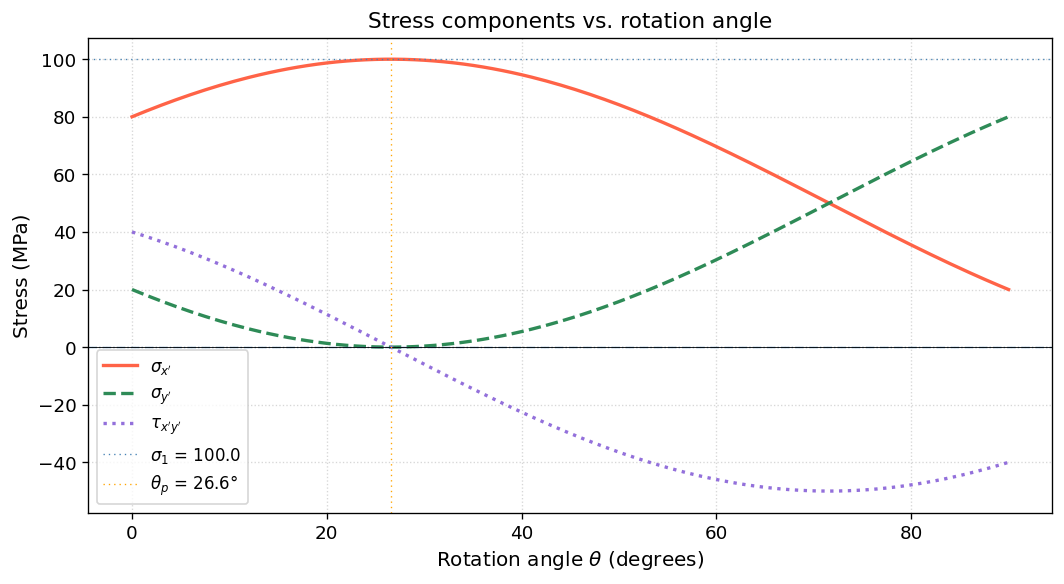

In [5]:
N_SWEEP = 181   # angle samples across 0-90 deg (0.5 deg steps)


def transform_plane_stress(sigma_x, sigma_y, tau_xy, theta_deg):
    """Rotate a plane-stress state and return the transformed components.

    Applies the standard stress-transformation equations. ``theta_deg`` is the
    physical rotation angle in degrees and may be a scalar or an array, so a
    whole sweep can be evaluated at once.

    Returns
    -------
    (sx_prime, sy_prime, tau_prime) : tuple of ndarray
        Normal stresses on the rotated x'- and y'-faces and the shear stress,
        in the same units as the inputs.
    """
    theta = np.radians(theta_deg)
    avg = (sigma_x + sigma_y) / 2.0
    half_diff = (sigma_x - sigma_y) / 2.0
    sx_prime = avg + half_diff * np.cos(2 * theta) + tau_xy * np.sin(2 * theta)
    sy_prime = avg - half_diff * np.cos(2 * theta) - tau_xy * np.sin(2 * theta)
    tau_prime = -half_diff * np.sin(2 * theta) + tau_xy * np.cos(2 * theta)
    return sx_prime, sy_prime, tau_prime


theta_deg = np.linspace(0, 90, N_SWEEP)
sx_prime, sy_prime, tau_prime = transform_plane_stress(sigma_x, sigma_y, tau_xy, theta_deg)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta_deg, sx_prime,  label=r"$\sigma_{x'}$",  color='tomato',       linewidth=2, linestyle='-')
ax.plot(theta_deg, sy_prime,  label=r"$\sigma_{y'}$",  color='seagreen',     linewidth=2, linestyle='--')
ax.plot(theta_deg, tau_prime, label=r"$\tau_{x'y'}$",  color='mediumpurple', linewidth=2, linestyle=':')

ax.axhline(sigma_1, color='steelblue', linewidth=0.8, linestyle=(0, (1, 3)),
           label=f'$\\sigma_1$ = {sigma_1:.1f}')
ax.axhline(sigma_2, color='steelblue', linewidth=0.8, linestyle='-.')
ax.axhline(0,       color='black',     linewidth=0.5)
ax.axvline(theta_p, color='orange',    linewidth=0.8, linestyle=(0, (1, 3)),
           label=f'$\\theta_p$ = {theta_p:.1f}°')

ax.set_xlabel(r'Rotation angle $\theta$ (degrees)', fontsize=12)
ax.set_ylabel(f'Stress ({units})', fontsize=12)
ax.set_title('Stress components vs. rotation angle', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig17_nb2_stress_transformation.png', bbox_inches='tight', dpi=SAVE_DPI)
plt.show()

## Reproducing the Chapter 17 worked example

With the default inputs ($\sigma_x = 80$ MPa, $\sigma_y = 20$ MPa, $\tau_{xy} = 40$ MPa), this notebook reproduces the worked example from the "Mohr's Circle for Stress" section of Chapter 17. The numbers agree line for line:

| Quantity | Chapter value | Notebook output |
|---|---|---|
| $\sigma_{avg}$ (center) | 50 MPa | 50.000 MPa |
| $R$ (radius) | 50 MPa | 50.000 MPa |
| $\sigma_1$ | 100 MPa | 100.000 MPa |
| $\sigma_2$ | 0 MPa | 0.000 MPa |
| $\tau_{max}$ | 50 MPa | 50.000 MPa |
| $\theta_p$ | 26.6° | 26.565° |

The circle above is Figure 17.3 in the book; the rotation sweep is Figure 17.4.

## A note on sign convention

This notebook follows the book's convention exactly. Tensile normal stress is positive, and **positive $\tau_{xy}$ is plotted upward** on the shear axis. The $x$-face becomes point A at $(\sigma_x, \tau_{xy})$ and the $y$-face becomes point B at $(\sigma_y, -\tau_{xy})$, so the diameter A–B runs through the center. Some textbooks instead plot positive shear *downward* to make the circle's rotation direction mirror the physical element; Chapter 17 plots positive shear upward, and so does this notebook. If your principal angle $\theta_p$ comes out with the opposite sign from another source, check which of these two conventions that source uses — the underlying geometry is identical.

## Where to take this next

The construction above is deliberately minimal — a foundation to extend. A few concrete directions:

1. **Drive it from a rosette, not from stresses.** Start one step earlier: take three readings from a rectangular (0°/45°/90°) strain rosette, apply the rosette equations to recover $\varepsilon_x$, $\varepsilon_y$, and $\gamma_{xy}$, then build the *strain* Mohr's circle. Remember the trap from Chapter 17 — plot $\gamma/2$, not $\gamma$, on the vertical axis. Convert the principal strains to principal stresses with Eq. (17.11), supplying $E$ and $\nu$ for your material.

2. **Animate the rotating element.** Draw the physical square element next to the circle and step $\theta$ from 0° to 90°, moving the element and its representative point on the circle together. Seeing them turn side by side makes the "circle angle is twice the physical angle" rule impossible to forget.

3. **Propagate measurement uncertainty.** Give each input a realistic tolerance (say $\pm 2$ MPa on the normal stresses and $\pm 1.5$ MPa on the shear), draw a few thousand *seeded* Monte-Carlo samples with `np.random.default_rng(0)`, and plot the resulting spread in $\sigma_1$ and $\theta_p$. This previews the uncertainty theme of Part 8 and shows concretely why a principal *stress* is an inference, while the principal *strain* it came from is a measurement.

---
*Companion to Chapter 17, "Mohr's Circle," of* Modern Strain Gage Technology *by Michael J. Bower.*